# Final project 

Jonatan Haraldsson

In [103]:
from pathlib import Path
import os

from astropy.nddata import CCDData
from astropy.visualization import hist
import ccdproc as ccdp
import matplotlib.pyplot as plt
import numpy as np
from astropy.nddata import CCDData
import matplotlib.pyplot as plt

In [421]:
# LaTeX font
plt.style.use('default')
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
font_size = 26
plt.rcParams['font.size'] = font_size

### Choose filter

In [2]:
filter_ = 'r'

### View the files

In [80]:


raw_data = Path(f'./{filter_}/', 'raw')
#raw_data = Path('.', 'raw')
raw_data.mkdir(exist_ok=True)

calibrated_data = Path(f'./{filter_}/', 'reduced')
# calibrated_data = Path('.', 'reduced')
calibrated_data.mkdir(exist_ok=True)


raw_path = Path(f'./{filter_}/raw')
raw_files = ccdp.ImageFileCollection(raw_path)
raw_files.summary['file', 'imagetyp', 'object', 'filter', 'exptime', 'naxis1', 'naxis2']

file,imagetyp,object,filter,exptime,naxis1,naxis2
str15,str6,str12,str1,float64,int64,int64
img.n2.1033.fit,OBJECT,Sky Flat i,i,5.0,1088,1024
img.n2.1034.fit,OBJECT,Sky Flat i,i,6.0,1088,1024
img.n2.1035.fit,OBJECT,Sky Flat i,i,7.0,1088,1024
img.n2.1036.fit,OBJECT,Sky Flat i,i,9.0,1088,1024
img.n2.1037.fit,OBJECT,Sky Flat i,i,11.0,1088,1024
img.n2.1110.fit,OBJECT,SN2017eaw i,i,50.0,1088,1024


Determine the overscan regions and loop over all files to subtract the overscan

In [81]:
start_x_overscan = 1071
start_x_science = 43
end_x_science = 1063

In [82]:
for ccd, file_name in raw_files.ccds(            
                                 ccd_kwargs={'unit': 'adu'}, # CCDData requires a unit for the image if 
                                                             # it is not in the header
                                 return_fname=True           # Provide the file name too.
                                ):
        # Subtract the overscan
    ccd = ccdp.subtract_overscan(ccd, overscan=ccd[:, start_x_overscan:], median=True)
    
    # Trim the overscan
    ccd = ccdp.trim_image(ccd[:, start_x_science:end_x_science])
    
    # Save the result
    ccd.write(calibrated_data / file_name, overwrite=True)

Double check that the files indeed were overscan subtracted

In [83]:
reduced_images = ccdp.ImageFileCollection(calibrated_data)
reduced_images.summary['file', 'imagetyp', 'object', 'naxis1', 'naxis2']

file,imagetyp,object,naxis1,naxis2
str17,str6,str12,int64,int64
combined_bias.fit,OBJECT,bias,1020,1024
img.n2.1033.fit,OBJECT,Sky Flat i,1020,1024
img.n2.1034.fit,OBJECT,Sky Flat i,1020,1024
img.n2.1035.fit,OBJECT,Sky Flat i,1020,1024
img.n2.1036.fit,OBJECT,Sky Flat i,1020,1024
img.n2.1037.fit,OBJECT,Sky Flat i,1020,1024
img.n2.1110.fit,OBJECT,SN2017eaw i,1020,1024


In [84]:
for ccd, file_name in raw_files.ccds(object=f'Sky Flat {filter_}',            # Just get the bias frames
                                         ccd_kwargs={'unit': 'adu'}, # CCDData requires a unit for the image if 
                                                                     # it is not in the header
                                         return_fname=True           # Provide the file name too.
                                        ):    
    # Subtract the overscan
    ccd = ccdp.subtract_overscan(ccd, overscan=ccd[:, start_x_overscan:], median=True)
    
    # Trim the overscan
    ccd = ccdp.trim_image(ccd[:, start_x_science:end_x_science])
    
    # Save the result; there are some duplicate file names so pre-pend "flat"
    ccd.write(calibrated_data / ('flat-' + file_name), overwrite=True)

In [85]:
from astropy.stats import mad_std

def inv_median(a):
    return 1 / np.median(a)

to_combine = reduced_images.files_filtered(object=f'Sky flat {filter_}', filter=filter_, include_path=True)
combined_flat = ccdp.combine(to_combine,
                                 method='average', scale=inv_median,
                                 sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                                 sigma_clip_func=np.ma.median, signma_clip_dev_func=mad_std,
                                 mem_limit=350e6
                                )

combined_flat.meta['combined'] = True
flat_file_name = 'combined_flat_filter_{}.fit'.format(filter_.replace("''", "p"))
combined_flat.write(calibrated_data / flat_file_name, overwrite=True)

In [86]:
from astropy import units as u

maskr = ccdp.ccdmask(combined_flat)
bad_pixel_mask = 'bad_pixel_mask.fit' #filter_{}.fit'.format(filt.replace("''", "p"))

mask_as_ccd = CCDData(data=maskr.astype('uint8'), unit=u.dimensionless_unscaled)
mask_as_ccd.header['imagetyp'] = 'flat mask'
mask_as_ccd.write(calibrated_data / 'mask_from_ccdmask.fits', overwrite=True)

In [87]:
combined_bias_list = reduced_images.files_filtered(include_path=True, object='bias')
print(combined_bias_list)

combined_bias = CCDData.read(combined_bias_list[0], unit='adu')

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


['i/reduced/combined_bias.fit']
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


In [88]:
# These two lists are created so that we have copies of the raw and calibrated images
# to later in the notebook. They are not ordinarily required.

for light, file_name in raw_files.ccds(object=f'SN2017eaw {filter_}', filter=filter_, return_fname=True, ccd_kwargs=dict(unit='adu')):
    
    reduced = ccdp.subtract_overscan(light, overscan=light[:, start_x_overscan:], median=True)
    
    reduced = ccdp.trim_image(reduced[:, start_x_science:end_x_science])
    
    reduced = ccdp.subtract_bias(reduced, combined_bias)
    
    reduced = ccdp.flat_correct(reduced, combined_flat)
        
    reduced.write(calibrated_data / file_name, overwrite=True)

## Actual processing 

In [24]:
import imexam
fil = "i"

paths = imexam.list_active_ds9()
viewer = imexam.connect(list(paths.keys())[0])


DS9 ds9 gs /tmp/.xpa/DS9_ds9.795095 haral080


ValueError: File for logging already specified,                                      turn off logging first.

In [26]:
viewer.load_fits(f'./{fil}/{fil}_new-image.fits')
viewer.rotate(180)
viewer.zoomtofit()
viewer.scale()

viewer.frame(2)
viewer.load_fits(f'./{fil}/raw/{fil}_science.fit')
viewer.rotate(180)
viewer.zoomtofit()
viewer.scale()

In [27]:
viewer.load_fits(f'./{fil}/{fil}_new-image.fits')
viewer.rotate(180)
viewer.zoomtofit()
viewer.scale()
viewer.setlog(on=False)


Press 'q' to quit

2 Make the next plot in a new window
a Aperture sum, with radius region_size 
b Return the 2D gauss fit center of the object
c Return column plot
d Return the Center of Mass fit center of the object
e Return a contour plot in a region around the cursor
g Return curve of growth plot
h Return a histogram in the region around the cursor
j 1D [Gaussian1D default] line fit 
k 1D [Gaussian1D default] column fit
l Return line plot
m Square region stats, in [region_size],default is median
r Return the radial profile plot
s Save current figure to disk as [plot_name]
t Make a fits image cutout using pointer location
w Display a surface plot around the cursor location
x Return x,y,value of pixel
y Return x,y,value of pixel
Current image /home/haral080/Final/r/r_new-image.fits
xc=288.8127	yc=643.4512
xc=416.9384	yc=428.2489
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
417.00         428.00         5          

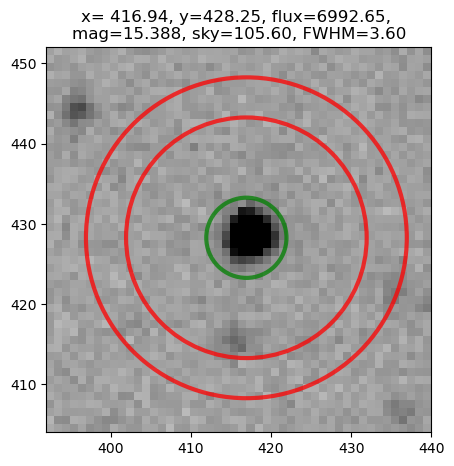

In [10]:
viewer.imexam()

Saving imexam commands to 'i_log.txt'

Press 'q' to quit

2 Make the next plot in a new window
a Aperture sum, with radius region_size 
b Return the 2D gauss fit center of the object
c Return column plot
d Return the Center of Mass fit center of the object
e Return a contour plot in a region around the cursor
g Return curve of growth plot
h Return a histogram in the region around the cursor
j 1D [Gaussian1D default] line fit 
k 1D [Gaussian1D default] column fit
l Return line plot
m Square region stats, in [region_size],default is median
r Return the radial profile plot
s Save current figure to disk as [plot_name]
t Make a fits image cutout using pointer location
w Display a surface plot around the cursor location
x Return x,y,value of pixel
y Return x,y,value of pixel
Current image /home/haral080/Final/i/i_new-image.fits
xc=815.7958	yc=177.5881
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
816.65         176.96      

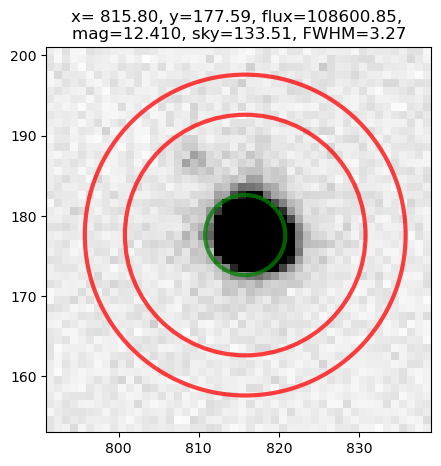

xc=772.2293	yc=39.3725
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
771.22         39.25          5              5.7e+04        13.112         128.108        1.52,1.43
772.2292754216838 39.37247084424547 24.0


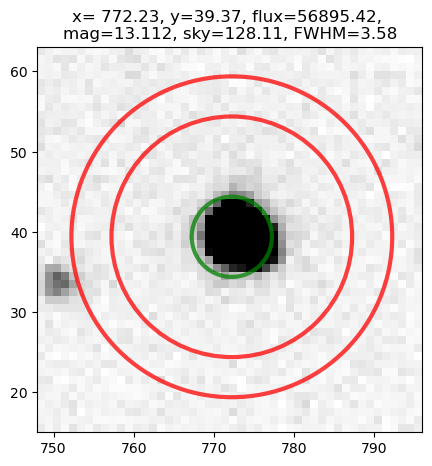

xc=374.0872	yc=284.0536
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
372.29         282.01         5              3.2e+04        13.735         134.714        1.33,1.41
374.08716846040295 284.0535798590663 24.0


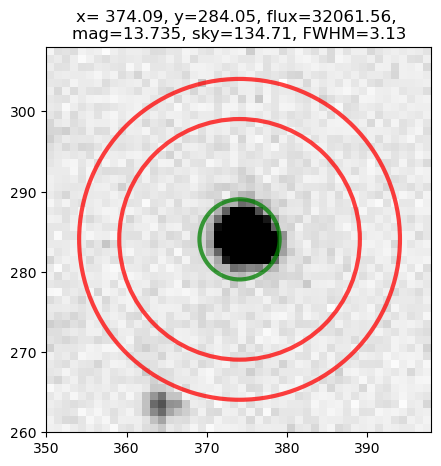

xc=116.5595	yc=532.7437
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
115.33         533.30         5              3.2e+04        13.728         129.883        1.48,1.21
116.55946679783892 532.7437423950715 24.0


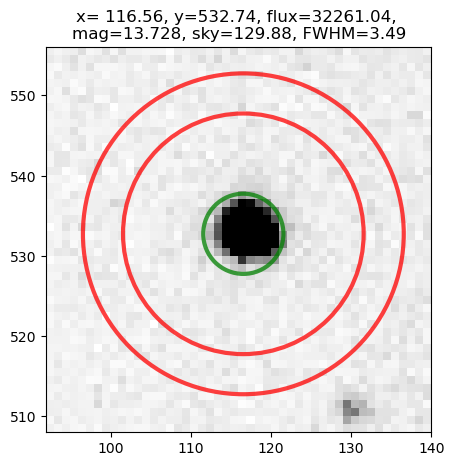

xc=716.5601	yc=214.4768
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
717.27         216.71         5              2.7e+04        13.920         134.490        1.38,1.46
716.5600783791543 214.47679787921916 24.0


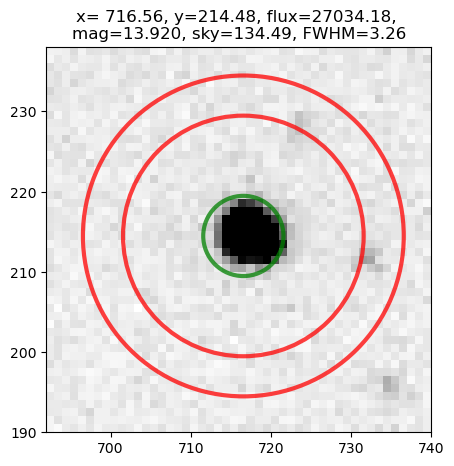

xc=182.8202	yc=81.7060
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
183.48         81.84          5              8.4e+03        15.193         127.775        1.57,1.41
182.82017106324287 81.70598595567175 24.0


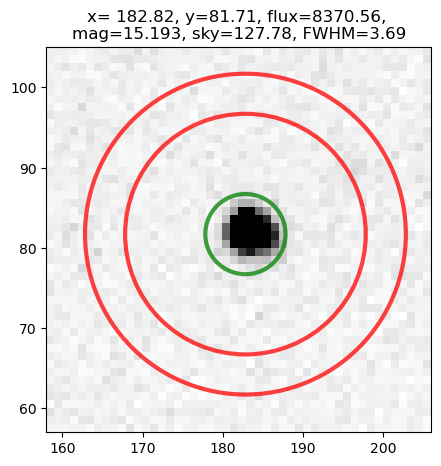

xc=402.0090	yc=361.4853
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
402.11         364.35         5              7.9e+04        12.754         137.381        1.38,1.29
402.0089609420376 361.48530656396775 24.0


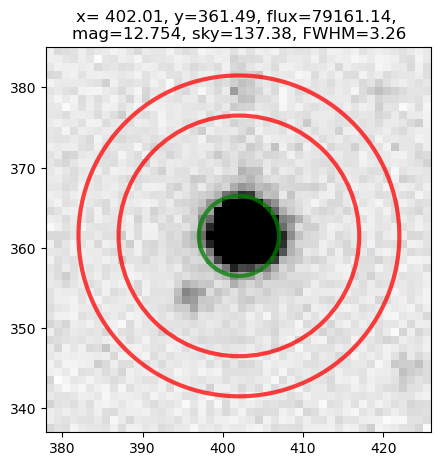

xc=928.5142	yc=63.9412
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
928.80         63.39          5              7.8e+03        15.267         126.152        1.56,1.43
928.5141726275239 63.94116665170904 24.0


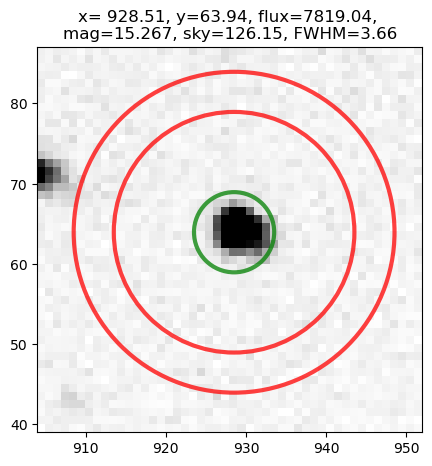

xc=931.7516	yc=527.4534
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
931.64         530.46         5              1.1e+04        14.903         141.549        1.27,1.45
931.7515925586599 527.4534448690484 24.0


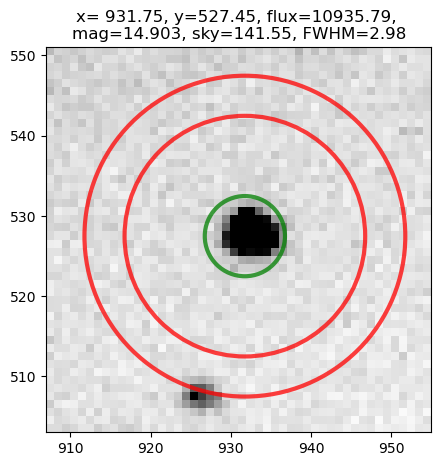

xc=281.8444	yc=1000.9227
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
281.43         1001.79        5              3e+04          13.812         136.086        1.50,1.09
281.8444377575206 1000.9227450176775 24.0


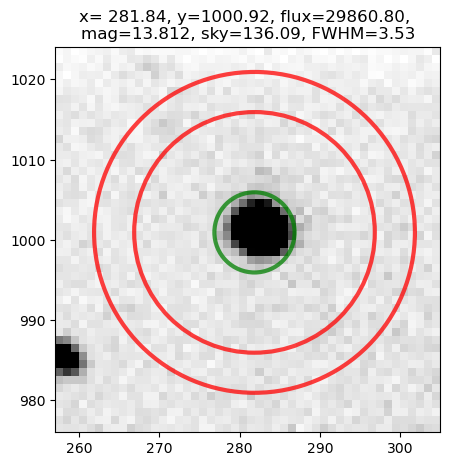

xc=71.1618	yc=872.6601
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
69.90          871.18         5              1.6e+05        12.011         132.740        1.13,1.59
71.16184321537908 872.6601156664403 24.0


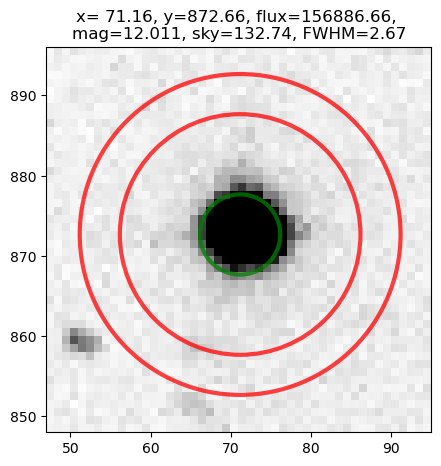

xc=110.8002	yc=405.8605
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
108.23         408.36         5              3.6e+04        13.609         131.100        1.50,1.25
110.80022286701171 405.86054820830265 24.0


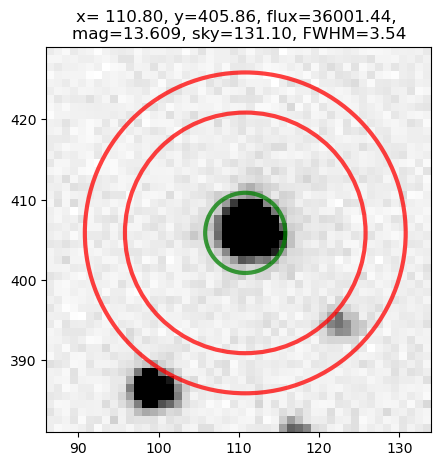

xc=58.2517	yc=249.5296
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
58.55          249.36         5              1e+04          14.950         126.586        1.34,1.61
58.251726462147715 249.52963406710404 24.0


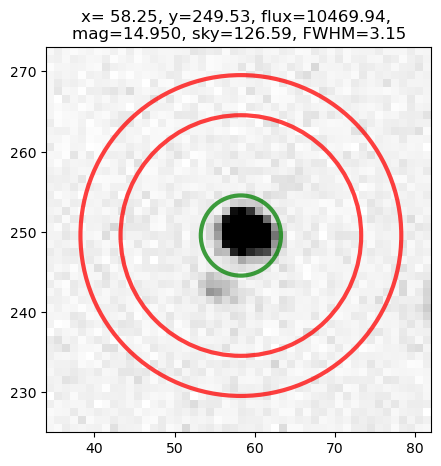

xc=313.9931	yc=305.0628
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
314.09         307.57         5              2e+04          14.261         133.901        1.32,1.44
313.9931448602369 305.06279472669655 24.0


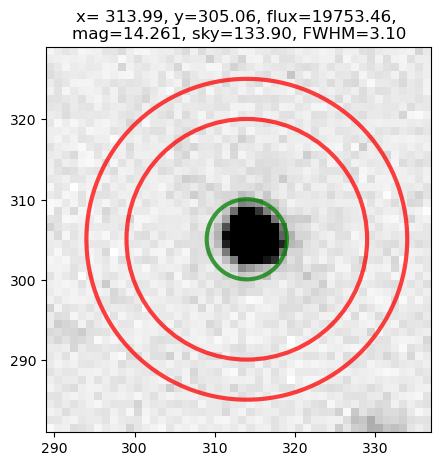

xc=313.7541	yc=359.4919
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
312.67         362.93         5              4.4e+04        13.400         141.818        1.43,1.27
313.75407736057866 359.4918965123582 24.0


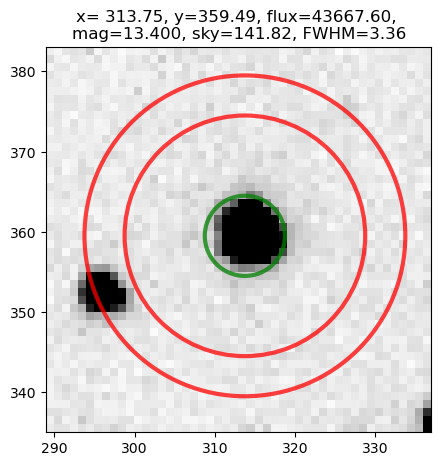

xc=485.9369	yc=425.1179
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
487.29         425.40         5              2.7e+04        13.916         140.750        1.36,1.28
485.93689216192865 425.1178978344057 24.0


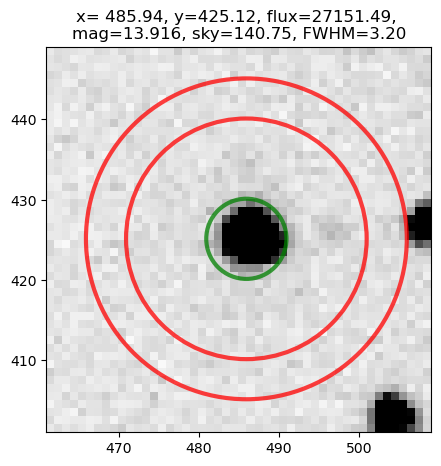

xc=931.7519	yc=527.4533
x              y              radius         flux           mag(zpt=25.000)               sky/pix        fwhm(x,y)
931.64         527.62         5              1.1e+04        14.903         141.549        1.45,1.27
931.7518993690433 527.4533290211891 24.0


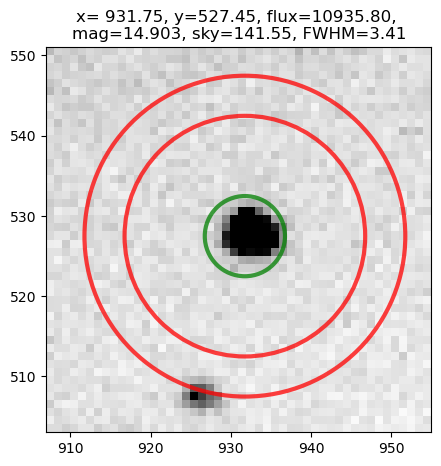

In [28]:
viewer.setlog(f'{fil}_log.txt',on=True)
viewer.imexam()

In [1]:
from astropy.wcs import WCS
from astropy.io import fits
from astropy.wcs import WCS

### Finding WCS for the $r$ band

In [495]:
import pandas as pd

def get_data(fil):
    data = np.genfromtxt(f'{fil}_log_1.txt', delimiter=',')
    return data[:,0],data[:,1],data[:,3],data[:,4]

def get_panstarr(fil, numstars = 10):
    MeanPSFMag = np.zeros(numstars)
    for i in range(1,(numstars+1)):
        data_psf = pd.read_csv(f'{fil}/pan/{fil}_star_{i}.csv')[f'{fil}MeanPSFMag']
        ind = (data_psf > -100)
        data = np.array(data_psf[ind])    

        data_sort = np.sort(data)
        MeanPSFMag[i-1] = np.min(data_sort[:])
    return MeanPSFMag

def find_offset(fil):
    mags = get_data(fil)[3]
    MeanPSFMag = get_panstarr(fil)

    #offset = 2.5 * np.log10(flux) + MeanPSFMag
    offset = MeanPSFMag - mags


    offset_diff = np.mean(offset) - offset

    offset_new_ = np.delete(offset,np.argmax(abs(offset_diff)))
    offset_diff = np.mean(offset) - offset_new_

    offset_new =  np.delete(offset_new_,np.argmax(abs(offset_diff)))
    
    zeropoint = np.mean(offset_new)
    zeropoint_std = np.std(offset_new)
    
    return np.mean(offset), np.std(offset), zeropoint, zeropoint_std

def magnitude(SN, zp,flux = False):
    if flux:
        return 2.5 * np.log10(SN) + zp
    else:
        return SN + zp

def r_R(V_R):
    if V_R <= 0.93:
        #print('First')
        return 0.267 * V_R + 0.88, (0.267 + 0.005) * V_R + (0.88 + 0.003) -  (0.267 * V_R + 0.88)
    else:
        #print('Second')
        return 0.77 * V_R - 0.37, (0.77 + 0.04) * V_R + (0.37 + 0.04) -  (0.77 * V_R + 0.37)

def g_B(B_V):
    return (-0.370)*(B_V) - (0.124), (-0.370 + 0.002)*(B_V) - (0.124 + 0.002) - ((-0.370)*(B_V) - (0.124))

def i_I(R_I):
    return (0.247)*(R_I) + (0.329),(0.247 + 0.003)*(R_I) + (0.329 + 0.002) - ((0.247)*(R_I) + (0.329))

def gen_table(fil):
    file = open(f'{fil}/{fil}_table.txt','w')
    x,y,flux,mag = get_data(fil)
    
    f = fits.open(f'./{fil}/{fil}_new-image.fits')
    w = WCS(f[0].header)
    PSF_mean = get_panstarr(fil)
    for i in range(0,10):
        xc = x[i]; yc = y[i]
        file.write(f'{i+1} & {xc} & {w.wcs_pix2world(xc, yc,1)[0]:.8f} & {PSF_mean[i]:.4f} & {mag[i]} & {(PSF_mean[i] - mag[i]):.4f} \\\ \n & {yc} & {w.wcs_pix2world(xc, yc,1)[1]:.8f} & & & \\\ \n \midrule \n')
    file.close()



<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/2845710726.py:67: SyntaxWarning: invalid escape sequence '\ '
  file.write(f'{i+1} & {xc} & {w.wcs_pix2world(xc, yc,1)[0]:.8f} & {PSF_mean[i]:.4f} & {mag[i]} & {(PSF_mean[i] - mag[i]):.4f} \\\ \n & {yc} & {w.wcs_pix2world(xc, yc,1)[1]:.8f} & & & \\\ \n \midrule \n')
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/2845710726.py:67: SyntaxWarning: invalid escape sequence '\ '
  file.write(f'{i+1} & {xc} & {w.wcs_pix2world(xc, yc,1)[0]:.8f} & {PSF_mean[i]:.4f} & {mag[i]} & {(PSF_mean[i] - mag[i]):.4f} \\\ \n & {yc} & {w.wcs_pix2world(xc, yc,1)[1]:.8f} & & & \\\ \n \midrule \n')


In [499]:
gen_table('i')

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/636187342.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[n].scatter(mag,get_panstarr(band),label = f'${band}$ band, $\\mathrm{{offset}} = {find_offset(band)[2]:.2f}\pm{find_offset(band)[3]:.4f}$', marker = 'o',color=color[n],s = 150)
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/636187342.py:12: SyntaxWarning: invalid escape sequence '\p'
  ax[n].set_title(f'${band}$ band, $\\mathrm{{offset}} = {find_offset(band)[2]:.2f}\pm{find_offset(band)[3]:.4f}$',fontsize=24)


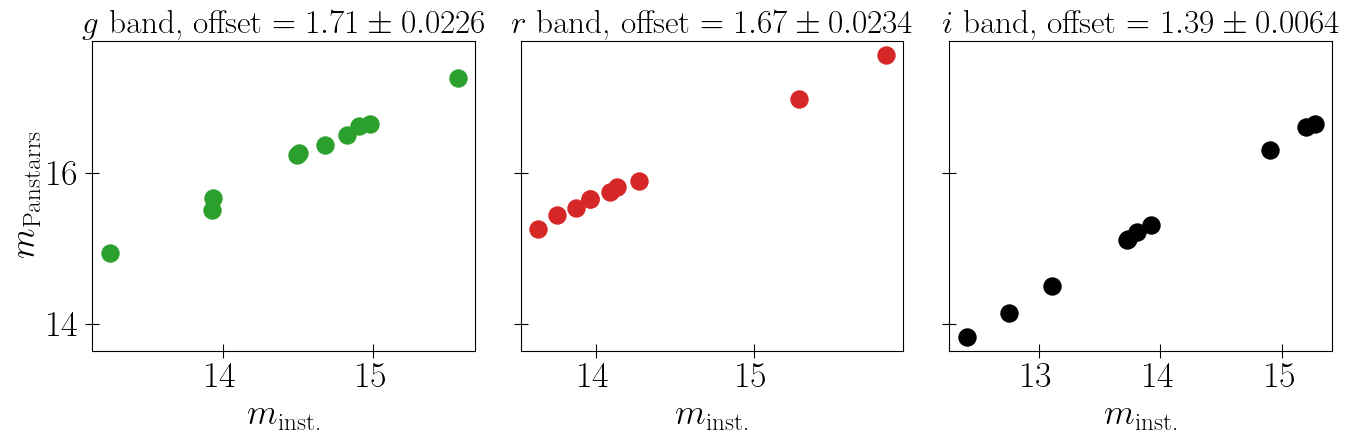

In [491]:
bands = ['g','r','i']
n = 0
color = ['tab:green','tab:red','k']

fig, ax = plt.subplots(1,3, figsize=(14,5),sharey=True)
ax[n].set_ylabel('$m_\\text{Panstarrs}$')
for band in bands:

    x,y,flux,mag = get_data(band)

    ax[n].scatter(mag,get_panstarr(band),label = f'${band}$ band, $\\mathrm{{offset}} = {find_offset(band)[2]:.2f}\pm{find_offset(band)[3]:.4f}$', marker = 'o',color=color[n],s = 150)
    ax[n].set_title(f'${band}$ band, $\\mathrm{{offset}} = {find_offset(band)[2]:.2f}\pm{find_offset(band)[3]:.4f}$',fontsize=24)
    ax[n].set_xlabel('$m_\\text{inst.}$')
    ax[n].tick_params(direction = 'inout',length = 10)
    #ax[n].grid(axis='y')
    n += 1
plt.tight_layout()
#plt.savefig('pan_min.pdf')

In [242]:
fil = 'i'
f = fits.open(f'./{fil}/{fil}_new-image.fits')
w = WCS(f[0].header)

file = open(f'{fil}/{fil}_WCS_csv.csv','w')
file.write('ra,dec\n')

x,y,flux,mag = get_data(fil)

for i in range(0,len(x)):
    xc = x[i]; yc = y[i]
    file.write(f'{w.wcs_pix2world(xc, yc,1)[0]},{w.wcs_pix2world(xc, yc,1)[1]}\n')
file.close()

In [496]:
fil = 'r'

f = fits.open(f'./{fil}/{fil}_new-image.fits')
w = WCS(f[0].header)

file = open(f'{fil}/{fil}_WCS.txt','w')
file.write('xpix\typix\tRa\tdec\tmag\n')

x,y,flux,mag = get_data(fil)

for i in range(0,len(x)):
    xc = x[i]; yc = y[i]
    file.write(f'{xc}\t{yc}\t{w.wcs_pix2world(xc, yc,1)[0]}\t{w.wcs_pix2world(xc, yc,1)[1]} \t {mag[i]} \n')
file.close()


x_SN = 552.5701; y_SN = 539.7399
print(f'{w.wcs_pix2world(x_SN, y_SN,1)[0]} \t {w.wcs_pix2world(x_SN, y_SN,1)[1]}')


308.68397467213407 	 60.19349654890049


### Measure the SN magnitude from `imexam`

In [ ]:
viewer.load_fits(f'./{fil}/{fil}_new-image.fits')
viewer.rotate(180)
viewer.zoomtofit()
viewer.scale()
viewer.setlog(on=False)

viewer.imexam()

### Printing the offsets

In [494]:
bands = ['g','r','i']

for band in bands:
    off = find_offset(band)
    print(f'${band}$ & ${off[0]:.2f} \\pm {off[1]:.3f}$ & ${off[2]:.2f} \\pm {off[3]:.3f}$')
    

$g$ & $1.70 \pm 0.047$ & $1.71 \pm 0.023$
$r$ & $1.67 \pm 0.031$ & $1.67 \pm 0.023$
$i$ & $1.40 \pm 0.011$ & $1.39 \pm 0.006$


In [493]:
SN_flux = [1.9e5,3.3e5, 2.8e5] # r, g , i
SN_mag = [11.793,11.199,11.381]
bands = ['g','r','i']
n = 0
V_R = 0.51; B_V = 1; R_I = 0.43

m_list = []
m_sig = []

for band in bands:
    zp = find_offset(band)[2]
    zp_std = find_offset(band)[3]
    m = magnitude(SN_mag[n],zp, flux =False)
    m_list.append(m)
    m_sig.append(zp_std)
    
    print(f'${band}$ & {SN_mag[n]:.3f} & ${m:.3f} \\pm {zp_std:.4f}$ & {zp:.3f} \\\ ')
    n+=1

$g$ & 11.793 & $13.499 \pm 0.0226$ & 1.706 \\ 
$r$ & 11.199 & $12.872 \pm 0.0234$ & 1.673 \\ 
$i$ & 11.381 & $12.775 \pm 0.0064$ & 1.394 \\ 


<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/4226007499.py:17: SyntaxWarning: invalid escape sequence '\ '
  print(f'${band}$ & {SN_mag[n]:.3f} & ${m:.3f} \\pm {zp_std:.4f}$ & {zp:.3f} \\\ ')


$B = 14.18 \pm 0.03$

$V = 13.18 \pm 0.01$

$R  = 12.67 \pm 0.02$

$I  = 12.24 \pm 0.02$

This means that $V-R = 13.18-12.67 = 0.51$, $B-V = 14.18 - 13.18 = 1$, and $R-I = 12.67 - 12.24 = 0.43$

In [472]:
B = 14.18; dB = 0.03
R = 12.67; dR = 0.02
I = 12.24; dI = 0.02
V = 13.18; dV = 0.01

print('band \t my value \t\t true')
V_R = V - R; B_V = B-V; R_I = R-I

m_B = -g_B(B_V)[0] + m_list[0]
m_g = g_B(B_V)[0]  + B
dm_g = abs(g_B(B_V)[1])  + abs(dB)
print(f'$g$ \t ${m_list[0]:.3f} \\pm {m_sig[0]:.3f}$ \t ${m_g:.3f} \\pm {dm_g:.3f}$ \\\ ')

m_r = r_R(V_R)[0] + R
dm_r = abs(r_R(V_R)[1]) + abs(dR)
print(f'$r$ \t ${m_list[1]:.3f} \\pm {m_sig[1]:.3f}$ \t ${m_r:.3f} \\pm {dm_r:.3f}$\\\ ')

m_i = i_I(R_I)[0] + I
dm_i = abs(i_I(R_I)[1]) + abs(dI)
print(f'$i$ \t ${m_list[2]:.3f} \\pm {m_sig[2]:.3f}$ \t ${m_i:.3f} \\pm {dm_i:.3f}$\\\ ')


print('---------------')
dm_B = abs(g_B(B_V)[1]) + abs(m_sig[0])
print(f'$B$ \t ${m_B:.3f} \\pm {dm_B:.3f}$ \t ${B} \\pm {dB}$\\\ ')

m_R = -r_R(V_R)[0] + m_list[1]
dm_R = abs(r_R(V_R)[1]) + abs(m_sig[1])
print(f'$R$ \t ${m_R:.3f} \\pm {dm_R:.3f}$ \t$ {R} \\pm {dR}$\\\ ')

m_I = -i_I(R_I)[0] + m_list[2]
dm_I = abs(i_I(R_I)[1]) + abs(m_sig[2])

print(f'$I $\t ${m_I:.3f} \\pm {dm_I:.3f}$ \t ${I} \\pm {dI}$\\\ ')



band 	 my value 		 true
$g$ 	 $13.499 \pm 0.023$ 	 $13.686 \pm 0.030$ \\ 
$r$ 	 $12.872 \pm 0.023$ 	 $12.693 \pm 0.080$\\ 
$i$ 	 $12.775 \pm 0.006$ 	 $12.675 \pm 0.023$\\ 
---------------
$B$ 	 $13.993 \pm 0.023$ 	 $14.18 \pm 0.03$\\ 
$R$ 	 $12.849 \pm 0.084$ 	$ 12.67 \pm 0.02$\\ 
$I $	 $12.339 \pm 0.010$ 	 $12.24 \pm 0.02$\\ 


<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/3247317677.py:12: SyntaxWarning: invalid escape sequence '\ '
  print(f'$g$ \t ${m_list[0]:.3f} \\pm {m_sig[0]:.3f}$ \t ${m_g:.3f} \\pm {dm_g:.3f}$ \\\ ')
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/3247317677.py:16: SyntaxWarning: invalid escape sequence '\ '
  print(f'$r$ \t ${m_list[1]:.3f} \\pm {m

### Extinction

To find the extinction corrected magnitudes, I used $m_{meas} = m_{int} + A_\lambda$

In [383]:
A_i = 0.583; A_r = 0.784; A_g = 1.134

A = [A_g, A_r, A_i]

d = 7.73e6
dd = 0.78e6

dist_mod = 5 * np.log10(d / 10)
print(dist_mod)
dist_mod = 5 * np.log10(d / 10)  - 5 * np.log10((d + dd) / 10) 
print(dist_mod)
dist_mod = 5 * np.log10(d / 10)  - 5 * np.log10((d - dd) / 10) 
print(dist_mod)

for i in range(3): 
    mag = m_list[i] - A[i]
    dmag = m_sig[i] 
    abs_mag = mag - 5 * np.log10(d / 10)
    M_max =  mag + dmag - 5 * np.log10((d - dd) / 10) - abs_mag 
    M_min =  mag - dmag - 5 * np.log10((d + dd) / 10) - abs_mag 
    print(f'${bands[i]}$ & {A[i] } &  ${mag:.2f} \\pm {dmag:.2f}$ & ${abs_mag:.2f}$ $({M_min:.2f},\\,+{M_max:.2f})$\\\ ')


29.440897469591626
-0.20875033083131456
0.2309734466410589
$g$ & 1.134 &  $12.36 \pm 0.05$ & $-17.08$ $(-0.26,\,+0.28)$\\ 
$r$ & 0.784 &  $12.09 \pm 0.03$ & $-17.35$ $(-0.24,\,+0.26)$\\ 
$i$ & 0.583 &  $12.20 \pm 0.01$ & $-17.24$ $(-0.22,\,+0.24)$\\ 


<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69216/2405633013.py:21: SyntaxWarning: invalid escape sequence '\ '
  print(f'${bands[i]}$ & {A[i] } &  ${mag:.2f} \\pm {dmag:.2f}$ & ${abs_mag:.2f}$ $({M_min:.2f},\\,+{M_max:.2f})$\\\ ')


https://ned.ipac.caltech.edu/cgi-bin/calc?in_csys=Equatorial&in_equinox=J2000.0&obs_epoch=2017.54383561644&lon=20%3A34%3A44.1539213121692+&lat=60%3A11%3A36.5875760414349+&pa=0.0&out_csys=Equatorial&out_equinox=J2000.0



Bandpass [µm]    | Aλ [mag]                              Bandpass [µm]     Aλ [mag]
---------------- | --------                              ----------------  --------
Landolt U (0.35) | 1.488                                 Landolt U (0.34)  1.857   
Landolt B (0.43)  | 1.245                                 Landolt B (0.44)  1.475   
Landolt V (0.54)  | 0.941                                 Landolt V (0.54)  1.133   
Landolt R (0.64) | 0.745                                 Landolt R (0.65)  0.914   
Landolt I (0.80) | 0.517                                 Landolt I (0.81)  0.663   
SDSS    u (0.36) | 1.455                                 SDSS    u (0.35)  1.762   
SDSS    g (0.47) | 1.134                                 SDSS    g (0.49)  1.296   
SDSS    r (0.62) | 0.784                                 SDSS    r (0.63)  0.940   
SDSS    i (0.75) | 0.583                                 SDSS    i (0.78)  0.713   
SDSS    z (0.89) | 0.434                                 SDSS    z (0.93)  0.505   
UKIRT   H (1.66) | 0.154                                 UKIRT   H (1.67)  0.197   
UKIRT   J (1.25) | 0.243                                 UKIRT   J (1.27)  0.308   
UKIRT   K (2.19) | 0.104                                 UKIRT   K (2.22)  0.125   
UKIRT   L'(3.78) | 0.053                                 UKIRT   L'(3.81)  0.052   

In [455]:
x = 0.6
b = 201.2
g = 3
D = 1.3
P = 3468

l = b * g * np.pi * D**2 / x**2
print((l))

k = P * g
s = k-l
print(k)
print(s)


print(s / np.sqrt(l))
print(s / np.sqrt(s + l))



8901.912223456919
10404
1502.0877765430814
15.920388379043052
14.726350750422366
